In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy import signal
import importlib
import joblib

In [2]:
import functions
importlib.reload(functions)

<module 'functions' from 'c:\\Users\\vacha\\OneDrive\\Desktop\\Programming\\Python\\Synapse\\functions.py'>

In [5]:
testdf = pd.read_csv("./Synapse_Dataset/Session1/session1_subject_1/gesture00_trial01.csv")
testdf

,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8
0,-0.060863,-0.059779,-0.070664,-0.099384,-0.109254,-0.179573,-0.197799,-0.099589
1,0.038164,0.033996,0.044030,0.058670,0.090746,0.090114,0.110890,0.059830
2,0.042375,0.025228,0.040711,0.069970,0.063638,0.152425,0.134781,0.083037
3,0.036794,0.032619,0.059910,0.076118,0.076880,0.082221,0.099097,0.062498
4,-0.017335,0.000019,0.029404,0.023640,-0.027965,-0.051400,-0.039817,-0.025009
...,...,...,...,...,...,...,...,...
2555,-0.025191,-0.021396,-0.024014,-0.027418,-0.051186,-0.010200,-0.027467,-0.029179
2556,-0.014335,-0.009781,-0.013091,-0.020603,-0.032430,-0.024619,-0.023339,-0.018662
2557,0.037174,0.040841,0.042998,0.051696,0.048475,0.025501,0.023241,0.027910
2558,0.078109,0.076382,0.083521,0.093143,0.092734,0.074405,0.074029,0.068954


In [7]:
fs = 512
raw = testdf.values
time = np.arange(raw.shape[0])/fs
raw

array([[-0.06086341, -0.05977894, -0.07066372, ..., -0.17957309,
        -0.19779948, -0.09958913],
       [ 0.03816386,  0.03399597,  0.04403033, ...,  0.09011362,
         0.11088979,  0.05982955],
       [ 0.04237479,  0.02522773,  0.04071085, ...,  0.15242532,
         0.13478141,  0.08303678],
       ...,
       [ 0.03717379,  0.04084146,  0.04299841, ...,  0.02550075,
         0.02324102,  0.02790965],
       [ 0.07810885,  0.0763818 ,  0.08352101, ...,  0.07440498,
         0.07402856,  0.06895447],
       [ 0.08731008,  0.08051478,  0.08807548, ...,  0.11165278,
         0.11264137,  0.09128546]], shape=(2560, 8))

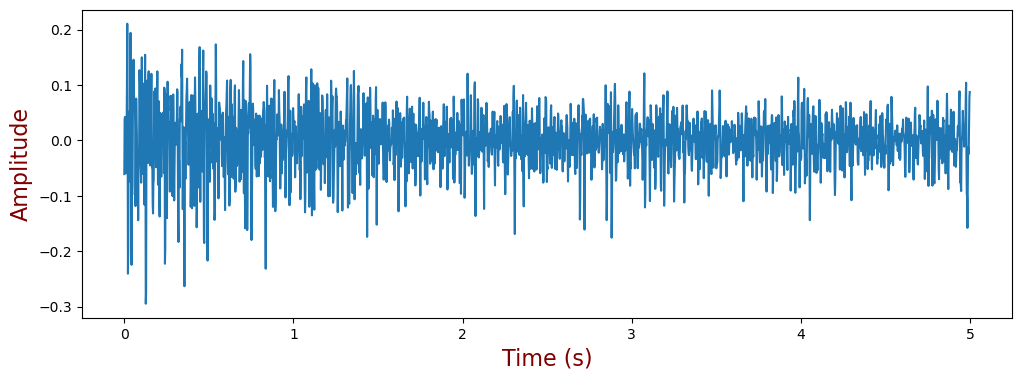

In [9]:
functions.plot(time, raw[:, 0])

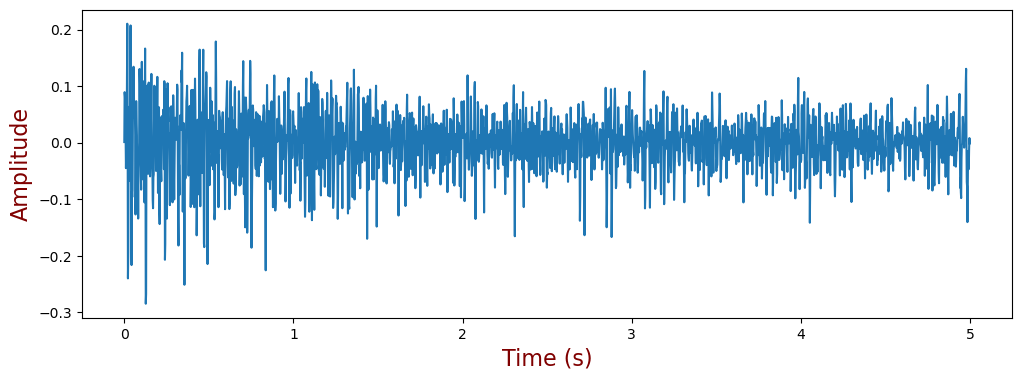

In [ ]:
filtered = functions.filtering(fs, raw)
functions.plot(time, filtered[:, 0])

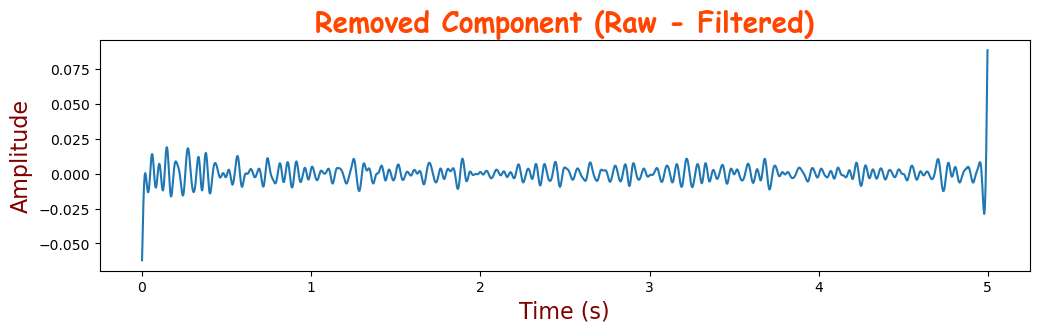

In [20]:
functions.visualizeFilter(time, raw[:, 0], filtered[:, 0])

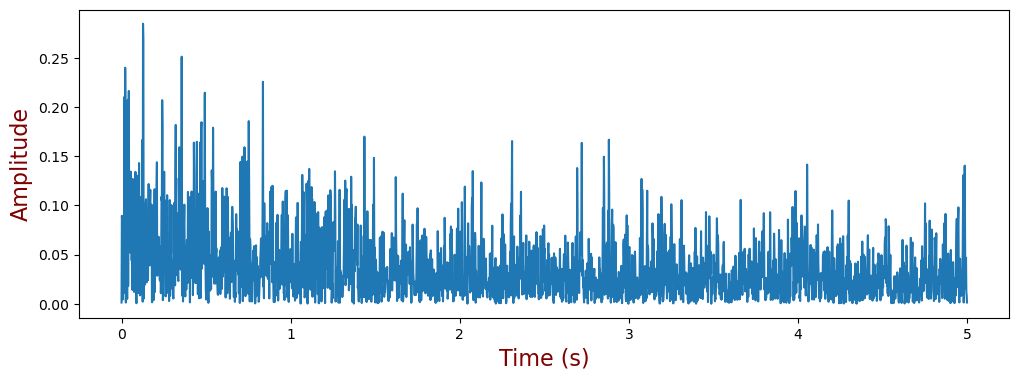

In [13]:
rectified = functions.rectify(filtered)
functions.plot(time, rectified[:, 0])

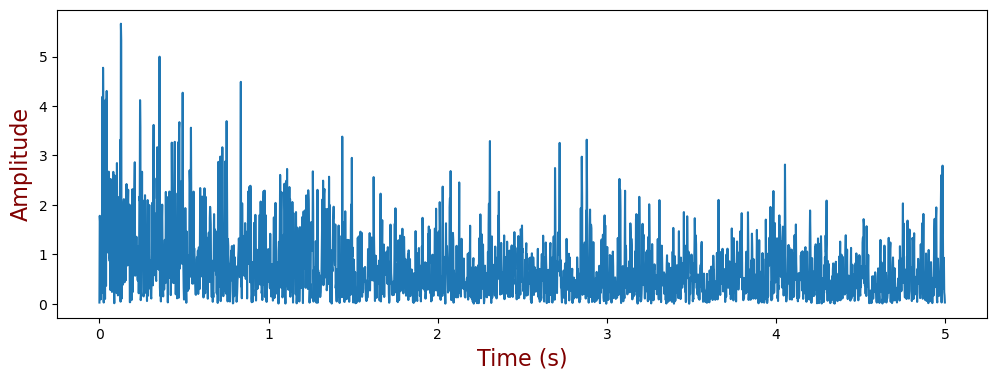

In [27]:
normalized = functions.normalize(rectified)
functions.plot(time, normalized[:, 0])

In [28]:
windowSize = 102 #(200ms)
overlap = 51 #50%
stride = windowSize - overlap

In [ ]:
windows = functions.windowing(normalized, windowSize, stride)
windows.shape
# Number of windows, window size, channels

(49, 102, 8)

In [32]:
windows[1].shape[1]

8

In [3]:
x, y, meta = joblib.load("MLdata.joblib")

In [5]:
x.shape

(128625, 32)

In [6]:
y.shape

(128625,)

In [10]:
meta

[{'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject': 1, 'session': 1, 'trial': 1},
 {'subject'

In [11]:
len(meta)

128625

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold